# 06 – Data Visualization: Price vs Sentiment

Visual exploration of the merged training datasets (price + FinBERT sentiment): per-ticker and combined.

Data source: `../data/processed/<TICKER>_training_dataset.csv` (from `O5_MergeData.ipynb`).

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.grid"] = True

TICKERS = ["AAPL", "AMZN", "GOOGL", "META", "MSFT", "NVDA", "TSLA"]
DATA_DIR = "../data/processed"

Matplotlib is building the font cache; this may take a moment.


In [3]:
def load_ticker(ticker):
    path = f"{DATA_DIR}/{ticker}_training_dataset.csv"
    if not os.path.exists(path):
        print(f"[skip] {ticker}: no training dataset")
        return None
    df = pd.read_csv(path, parse_dates=["Date"])
    return df.sort_values("Date").reset_index(drop=True)


data = {}
for t in TICKERS:
    df = load_ticker(t)
    if df is not None:
        data[t] = df

print("Loaded tickers:", list(data.keys()))
for t, df in data.items():
    print(f"  {t}: {len(df)} rows, {df['Date'].min().date()} -> {df['Date'].max().date()}")

Loaded tickers: ['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA']
  AAPL: 45 rows, 2020-04-06 -> 2020-06-09
  AMZN: 11 rows, 2020-05-26 -> 2020-06-09
  GOOGL: 452 rows, 2018-08-22 -> 2020-06-09
  META: 1232 rows, 2021-08-27 -> 2026-07-27
  MSFT: 1232 rows, 2021-08-27 -> 2026-07-27
  NVDA: 2313 rows, 2011-03-31 -> 2020-06-09
  TSLA: 218 rows, 2019-07-30 -> 2020-06-09


## Per-ticker: Price vs Sentiment

Dual-axis: Close price (left) vs daily average sentiment and its EMA-decayed version `SentimentEMA` (right, span=5 weighted decay).

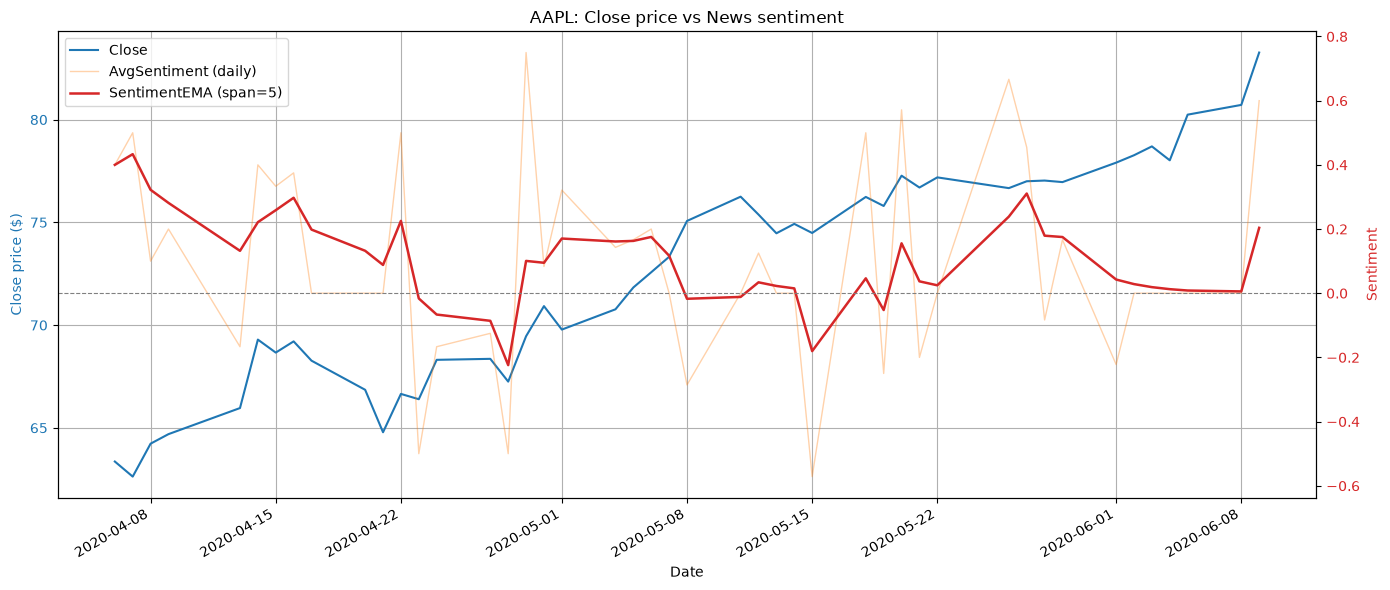

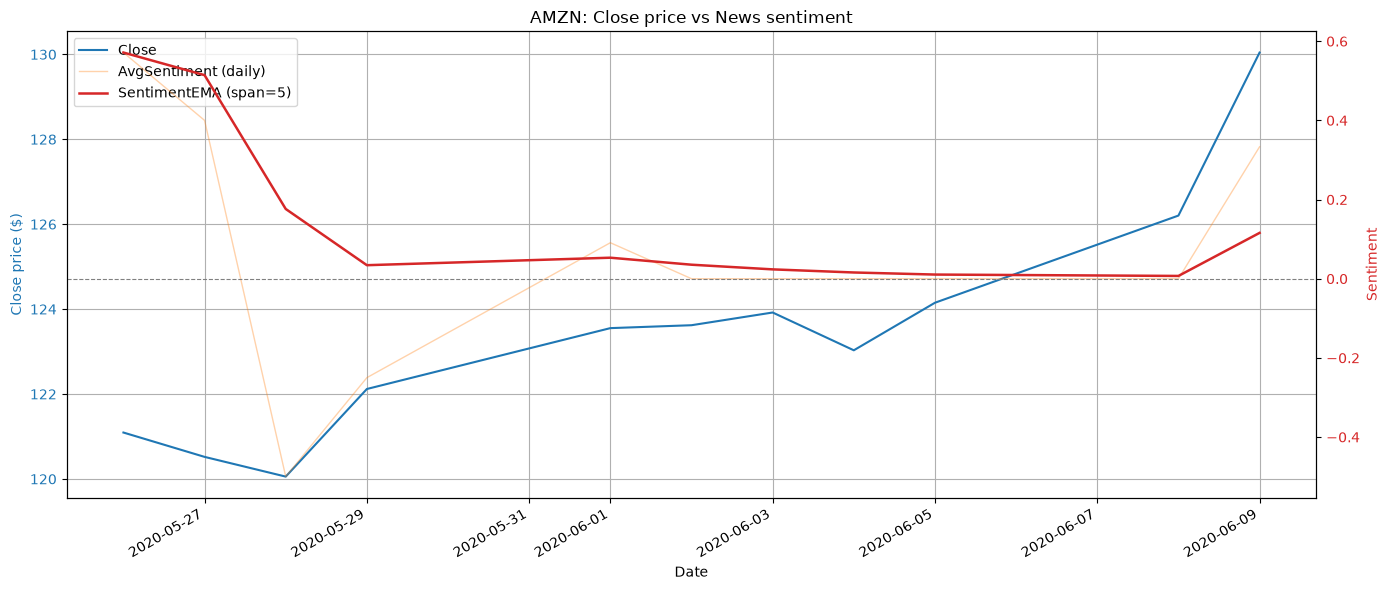

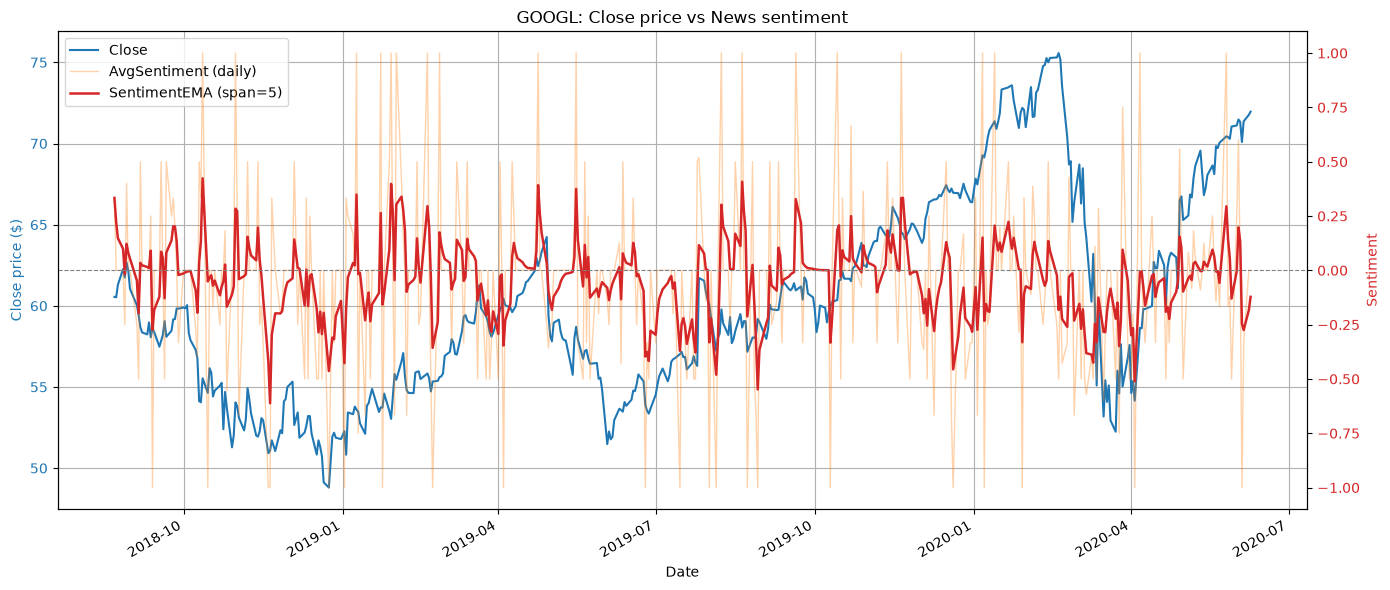

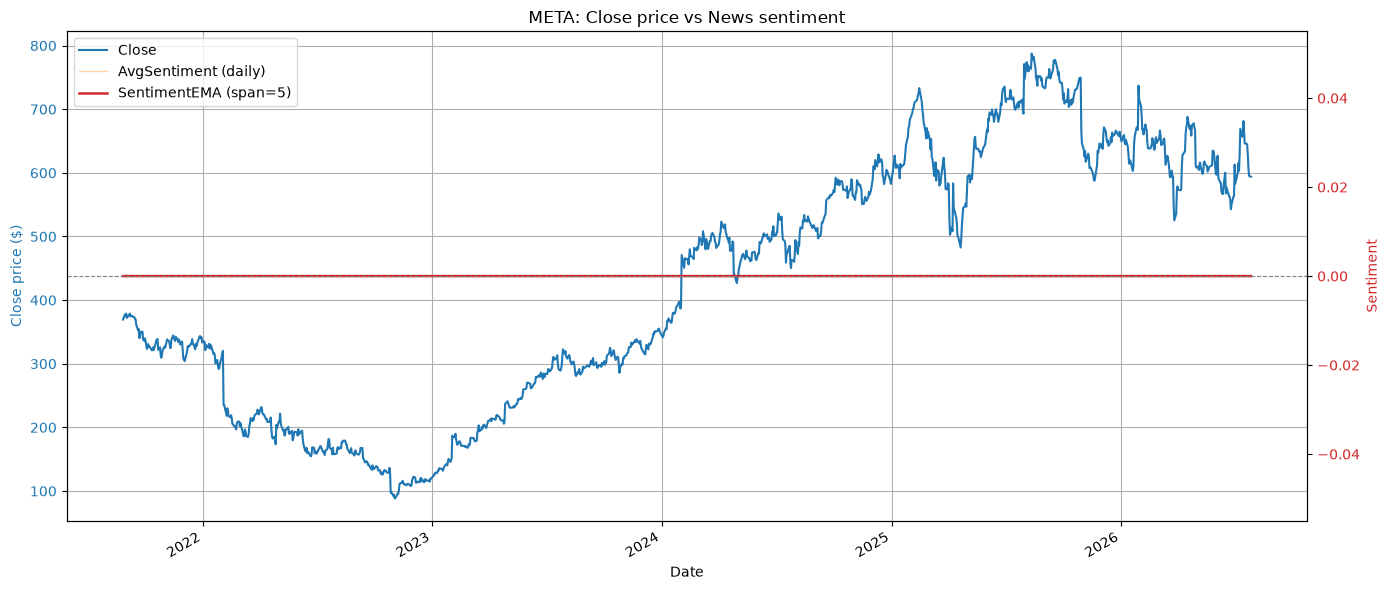

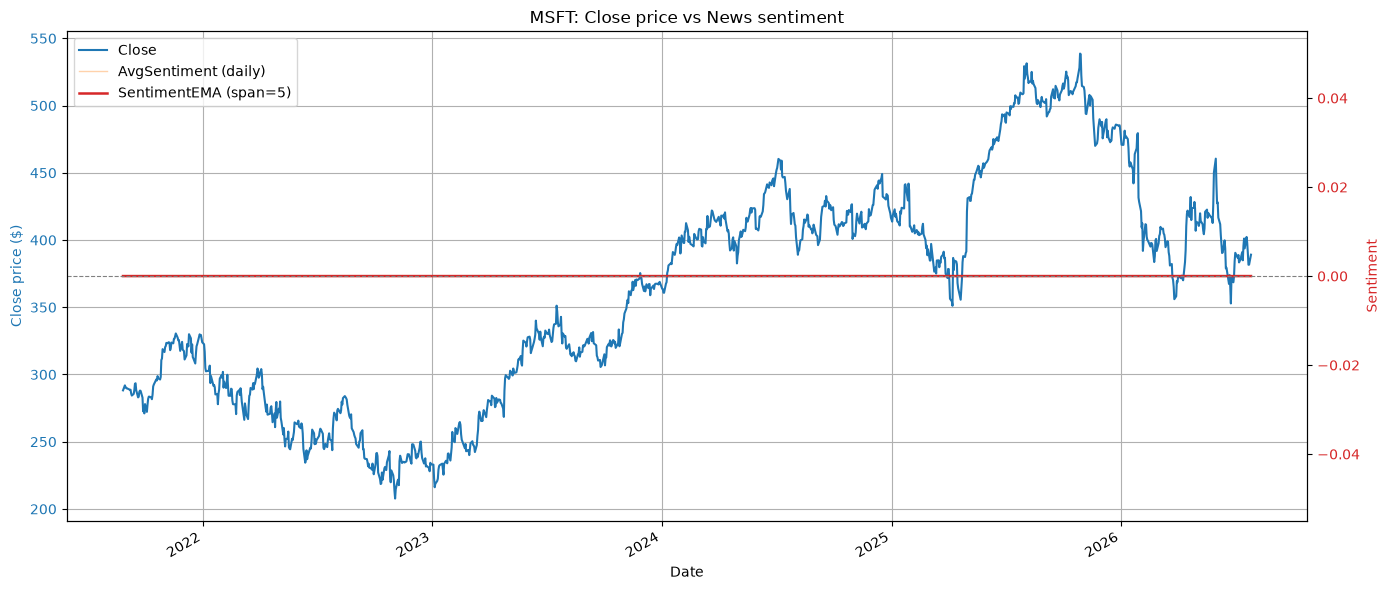

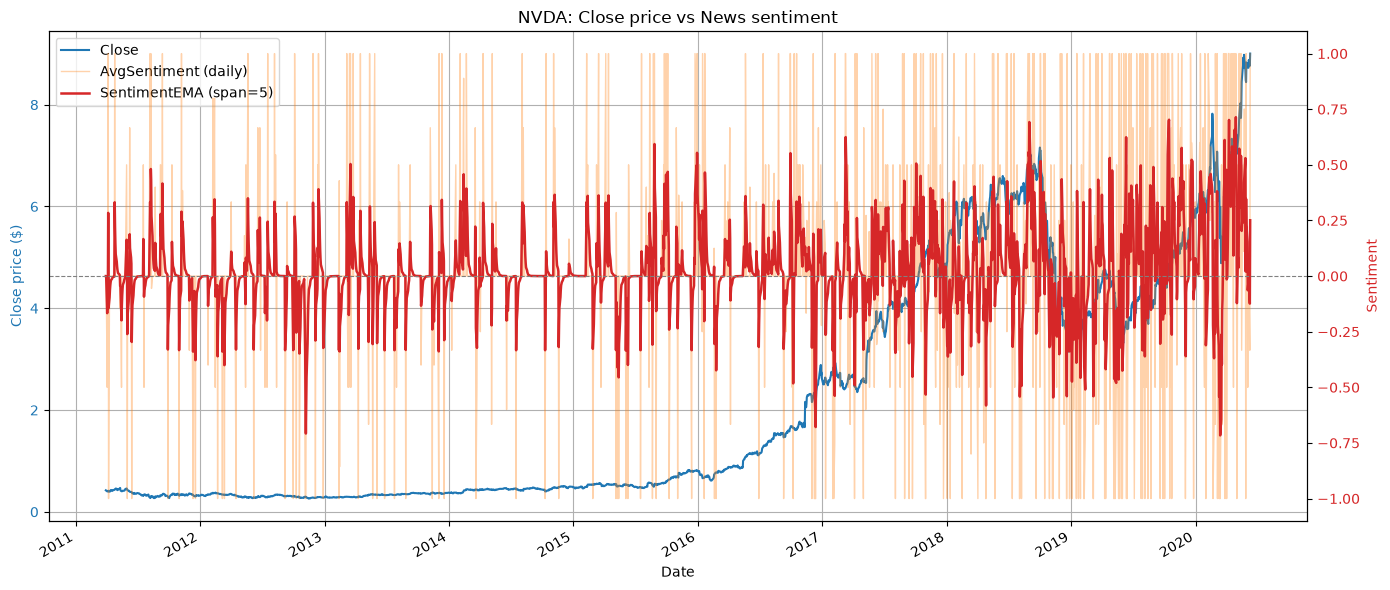

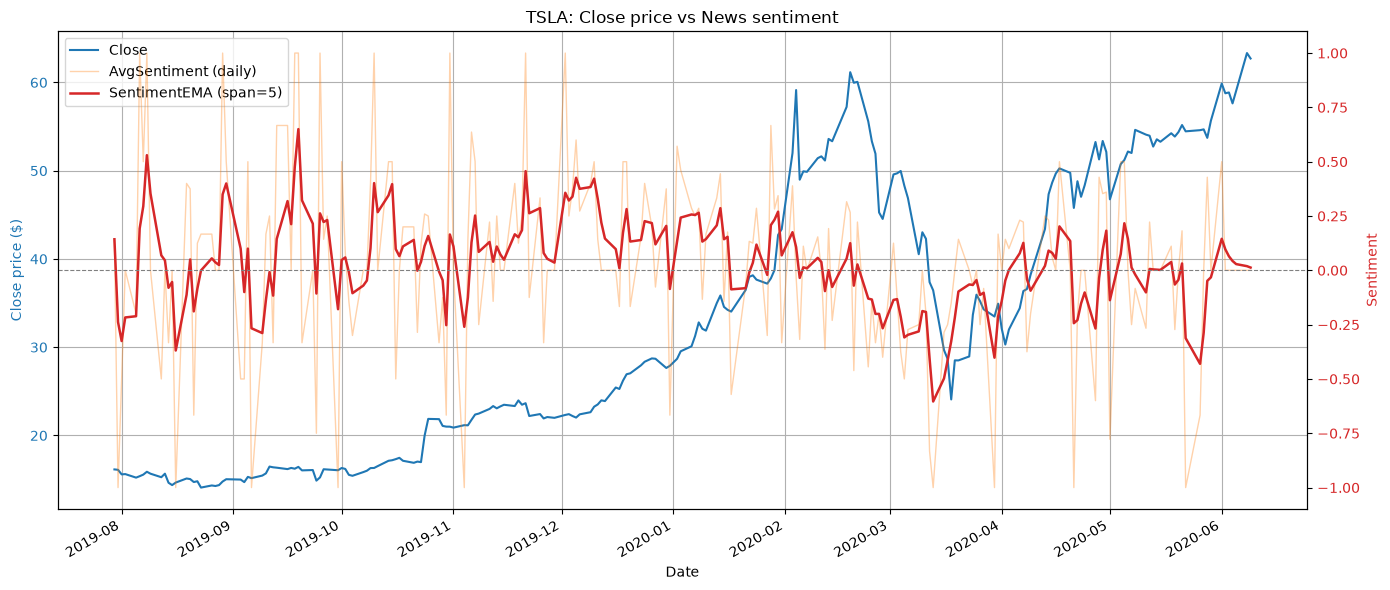

In [4]:
def plot_price_vs_sentiment(ticker, df):
    fig, ax_price = plt.subplots()
    ax_price.plot(df["Date"], df["Close"], color="#1f77b4", linewidth=1.5, label="Close")
    ax_price.set_ylabel("Close price ($)", color="#1f77b4")
    ax_price.tick_params(axis="y", labelcolor="#1f77b4")
    ax_price.set_xlabel("Date")

    ax_sent = ax_price.twinx()
    ax_sent.plot(df["Date"], df["AvgSentiment"], color="#ff7f0e", alpha=0.35, linewidth=1, label="AvgSentiment (daily)")
    if "SentimentEMA" in df.columns:
        ax_sent.plot(df["Date"], df["SentimentEMA"], color="#d62728", linewidth=1.8, label="SentimentEMA (span=5)")
    ax_sent.axhline(0, color="grey", linewidth=0.8, linestyle="--")
    ax_sent.set_ylabel("Sentiment", color="#d62728")
    ax_sent.tick_params(axis="y", labelcolor="#d62728")
    ax_sent.grid(False)

    l1, lab1 = ax_price.get_legend_handles_labels()
    l2, lab2 = ax_sent.get_legend_handles_labels()
    ax_price.legend(l1 + l2, lab1 + lab2, loc="upper left")
    ax_price.set_title(f"{ticker}: Close price vs News sentiment")
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()


for t, df in data.items():
    plot_price_vs_sentiment(t, df)

## Combined: Normalized price across all tickers

Prices rebased to 100 at each ticker's first date so trajectories are comparable.

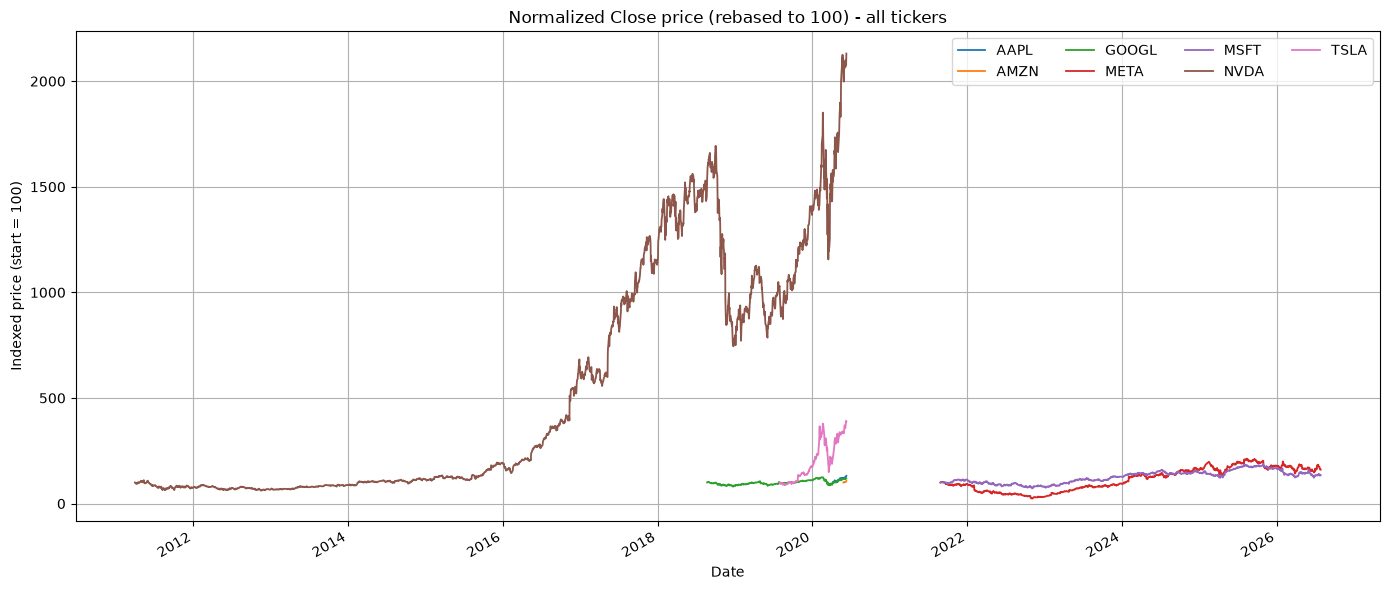

In [5]:
fig, ax = plt.subplots()
for t, df in data.items():
    norm = df["Close"] / df["Close"].iloc[0] * 100
    ax.plot(df["Date"], norm, linewidth=1.3, label=t)
ax.set_title("Normalized Close price (rebased to 100) - all tickers")
ax.set_xlabel("Date")
ax.set_ylabel("Indexed price (start = 100)")
ax.legend(ncol=4)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Combined: EMA-decayed sentiment across all tickers

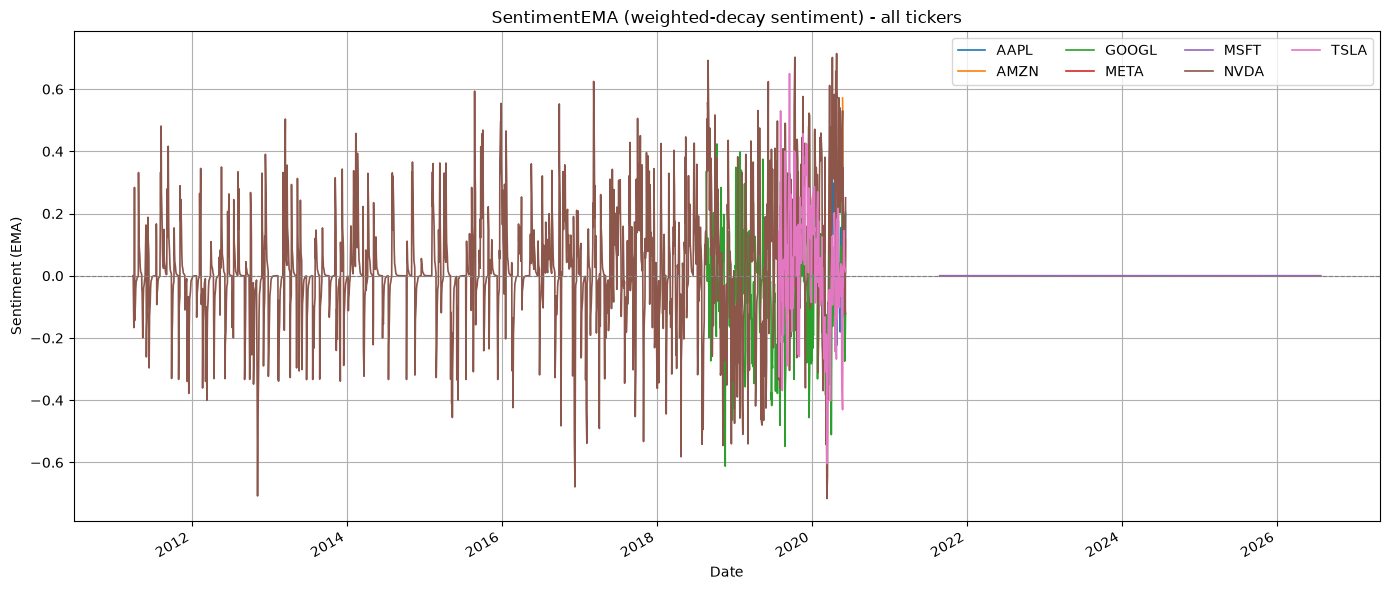

In [6]:
sent_col = "SentimentEMA"
fig, ax = plt.subplots()
for t, df in data.items():
    if sent_col in df.columns:
        ax.plot(df["Date"], df[sent_col], linewidth=1.2, label=t)
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_title(f"{sent_col} (weighted-decay sentiment) - all tickers")
ax.set_xlabel("Date")
ax.set_ylabel("Sentiment (EMA)")
ax.legend(ncol=4)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Sentiment vs next-day movement

Mean `SentimentEMA` on news days, split by whether the stock rose the next day.

TomorrowUp
Down next day    0.020723
Up next day      0.020375
Name: SentimentEMA, dtype: float64


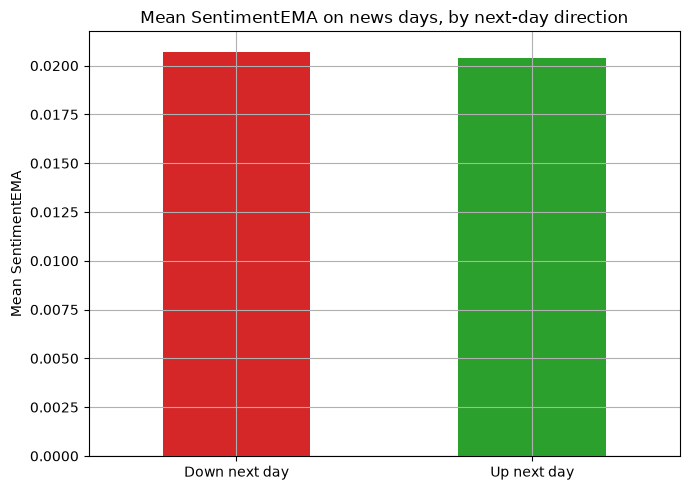

In [7]:
combined = pd.concat(data.values(), ignore_index=True)
has_news = combined[combined["HeadlineCount"] > 0]

grouped = (
    has_news.groupby("TomorrowUp")["SentimentEMA"]
    .mean()
    .rename({0: "Down next day", 1: "Up next day"})
)
print(grouped)

fig, ax = plt.subplots(figsize=(7, 5))
grouped.plot(kind="bar", color=["#d62728", "#2ca02c"], ax=ax)
ax.set_title("Mean SentimentEMA on news days, by next-day direction")
ax.set_ylabel("Mean SentimentEMA")
ax.set_xlabel("")
ax.axhline(0, color="grey", linewidth=0.8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Correlation heatmap: sentiment features vs next-day movement

Pearson correlation between the sentiment features (`AvgSentiment`, `SentimentEMA`, `AvgConfidence`, `HeadlineCount`) and the next-day outcome (`TomorrowUp`, `Daily_Return`). Values near 0 mean little linear relationship.

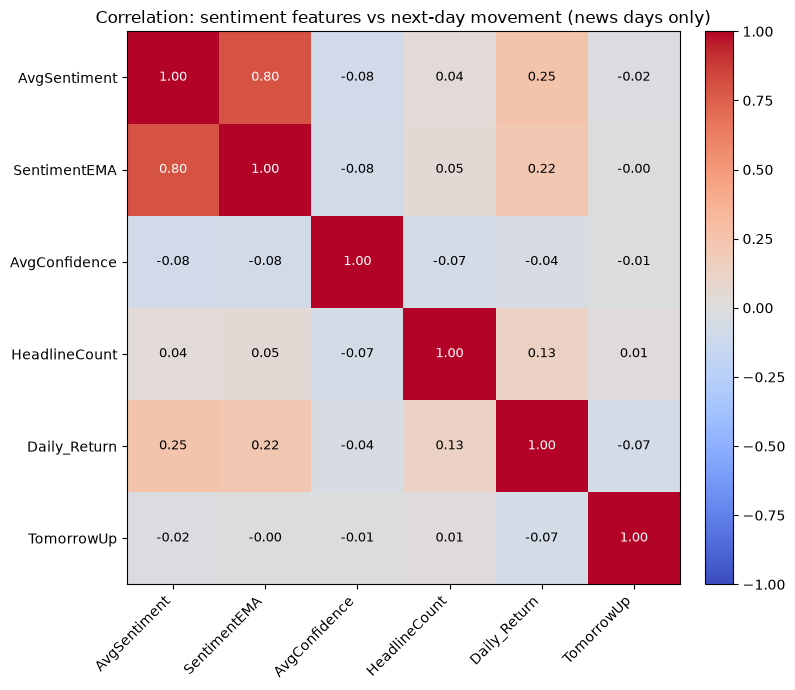

Correlation with TomorrowUp:
TomorrowUp       1.000000
HeadlineCount    0.013388
SentimentEMA    -0.000773
AvgConfidence   -0.012874
AvgSentiment    -0.020584
Daily_Return    -0.068897
Name: TomorrowUp, dtype: float64


In [9]:
import numpy as np

cols = ["AvgSentiment", "SentimentEMA", "AvgConfidence", "HeadlineCount", "Daily_Return", "TomorrowUp"]
cols = [c for c in cols if c in combined.columns]

# Use only rows with news so zero-filled days don't wash out the signal
corr = combined.loc[combined["HeadlineCount"] > 0, cols].corr()

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha="right")
ax.set_yticklabels(cols)

# annotate each cell with the correlation value
for i in range(len(cols)):
    for j in range(len(cols)):
        val = corr.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                color="white" if abs(val) > 0.5 else "black", fontsize=9)

ax.set_title("Correlation: sentiment features vs next-day movement (news days only)")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.grid(False)
plt.tight_layout()
plt.show()

# focused view: correlation of each feature with TomorrowUp
print("Correlation with TomorrowUp:")
print(corr["TomorrowUp"].sort_values(ascending=False))

## Observations

- Price and the EMA-smoothed sentiment tend to move together during sharp news-driven swings; raw daily sentiment is noisy, so the weighted-decay `SentimentEMA` is easier to read.
- Many trading days have no news (filled with 0 in the merge), so the raw sentiment line frequently drops to zero; the EMA bridges those gaps.
- All 7 names trend upward in the normalized-price chart, with NVDA/TSLA the steepest.
- **Sentiment vs next-day direction:** mean `SentimentEMA` on news days is ~0.0204 before up-days and ~0.0207 before down-days — a ~0.0003 gap (essentially zero, and slightly higher before *down* days). So `SentimentEMA` has **no standalone linear signal** for next-day direction on this sample.
- This does **not** mean sentiment is useless: no-news days were zero-filled (diluting the mean), the sample/window is small, and any effect could be non-linear or lagged. We let the Week-3 models (RF/XGBoost) + SHAP judge sentiment's real, possibly conditional, contribution alongside the technical indicators.
- **Correlation heatmap:** `AvgSentiment` and `SentimentEMA` show near-zero correlation with `TomorrowUp`, confirming the bar-chart finding — no linear predictive edge on their own. (`AvgSentiment` and `SentimentEMA` correlate strongly with each other, as expected since the EMA is derived from the daily average.)